In [ ]:
import pandas as pd

# Load Dataset 
df = pd.read_csv(r"C:\Users\brswe\Downloads\may_2026_assignment\ai_project_synthetic_datasets\part_3_nlp_sequence_modeling\customer_support_text_classification.csv")

# Basic Exploration 
print("Shape:")
print(df.shape)

print("\nList of all Columns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
print(df.head())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nTarget Variable Distribution:")
print(df['sentiment_label'].value_counts())

print("\nTarget Variable Percentage:")
print(df['sentiment_label'].value_counts(normalize=True) * 100)

print("\nSample Messages:")
for i in range(3):
    print(f"\n  Message  : {df['customer_message'][i]}")
    print(f"  Sentiment: {df['sentiment_label'][i]}")

Shape:
(1500, 6)

Columns:
['ticket_id', 'channel', 'customer_message', 'sentiment_label', 'word_count', 'urgent_flag']

First 5 rows:
  ticket_id channel                                   customer_message  \
0  TKT00001    chat  I need information about the payment process. ...   
1  TKT00002   phone      I need information about the payment process.   
2  TKT00003   email  The refund process was fast and convenient. I ...   
3  TKT00004  social  My refund is still pending and this experience...   
4  TKT00005    chat   Please tell me how to update my account details.   

  sentiment_label  word_count  urgent_flag  
0         neutral          18            1  
1         neutral           7            0  
2        positive          12            0  
3        negative          15            1  
4         neutral           9            0  

Data Types:
ticket_id             str
channel               str
customer_message      str
sentiment_label       str
word_count          int64
urgent_

In [2]:
import pandas as pd
import numpy as np
import re
import string

# Load Dataset 
df = pd.read_csv(r"C:\Users\brswe\Downloads\may_2026_assignment\ai_project_synthetic_datasets\part_3_nlp_sequence_modeling\customer_support_text_classification.csv")

# Step 1: Keep only useful columns 
# We only need the message and the label
df = df[['customer_message', 'sentiment_label']]
print("Columns kept:", df.columns.tolist())

# Step 2: Check for missing values 
print("\nMissing Values:")
print(df.isnull().sum())

# Step 3: Clean the text 
def clean_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove punctuation like . , ! ? etc
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove extra spaces
    text = text.strip()

    return text

# Apply cleaning to every message
df['cleaned_message'] = df['customer_message'].apply(clean_text)

print("\nBefore and After Cleaning:")
for i in range(3):
    print(f"\n  Original : {df['customer_message'][i]}")
    print(f"  Cleaned  : {df['cleaned_message'][i]}")

# Step 4: Encode target labels into numbers 
# Machine learning models need numbers not text
# positive → 2, neutral → 1, negative → 0
label_map = {'negative': 0, 'neutral': 1, 'positive': 2}
df['label'] = df['sentiment_label'].map(label_map)

print("\nLabel Encoding:")
print(df[['sentiment_label', 'label']].drop_duplicates())

# Step 5: Check class distribution 
print("\nClass Distribution:")
print(df['sentiment_label'].value_counts())

print("\nClass Distribution (%):")
print(df['sentiment_label'].value_counts(normalize=True) * 100)

# Step 6: Show final cleaned dataset 
print("\nFinal Dataset Sample:")
print(df[['cleaned_message', 'sentiment_label', 'label']].head())
print("\nShape:", df.shape)

Columns kept: ['customer_message', 'sentiment_label']

Missing Values:
customer_message    0
sentiment_label     0
dtype: int64

Before and After Cleaning:

  Original : I need information about the payment process. My ticket number is 78732. Please respond as soon as possible.
  Cleaned  : i need information about the payment process my ticket number is  please respond as soon as possible

  Original : I need information about the payment process.
  Cleaned  : i need information about the payment process

  Original : The refund process was fast and convenient. I appreciate the quick response.
  Cleaned  : the refund process was fast and convenient i appreciate the quick response

Label Encoding:
  sentiment_label  label
0         neutral      1
2        positive      2
3        negative      0

Class Distribution:
sentiment_label
neutral     524
negative    497
positive    479
Name: count, dtype: int64

Class Distribution (%):
sentiment_label
neutral     34.933333
negative    33.1333

In [3]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
import torch
import numpy as np

# ── Why Text Must Be Converted to Vectors ─────────────────────────────────────
print("""
WHY TEXT MUST BE CONVERTED TO VECTORS:
Machine learning models only understand numbers, not words.
So we must convert text into numerical format before training.
This process is called Text Vectorization.
""")

# ── Prepare Data ──────────────────────────────────────────────────────────────
X = df['cleaned_message']
y = df['label']

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training samples : {len(X_train)}")
print(f"Testing  samples : {len(X_test)}")

# ── Method 1: Bag of Words (BOW) ──────────────────────────────────────────────
print("\n" + "=" * 50)
print("METHOD 1: Bag of Words (BOW)")
print("=" * 50)

# BOW counts how many times each word appears in a message
bow_vectorizer = CountVectorizer(max_features=1000)
X_train_bow    = bow_vectorizer.fit_transform(X_train)
X_test_bow     = bow_vectorizer.transform(X_test)

print(f"BOW Matrix Shape (Train) : {X_train_bow.shape}")
print(f"BOW Matrix Shape (Test)  : {X_test_bow.shape}")
print(f"Vocabulary Size          : {len(bow_vectorizer.vocabulary_)}")
print(f"Sample words in vocab    : {list(bow_vectorizer.vocabulary_.keys())[:10]}")

# ── Method 2: TF-IDF ──────────────────────────────────────────────────────────
print("\n" + "=" * 50)
print("METHOD 2: TF-IDF")
print("=" * 50)

# TF-IDF gives higher score to important words and lower score to common words
tfidf_vectorizer = TfidfVectorizer(max_features=1000)
X_train_tfidf    = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf     = tfidf_vectorizer.transform(X_test)

print(f"TF-IDF Matrix Shape (Train) : {X_train_tfidf.shape}")
print(f"TF-IDF Matrix Shape (Test)  : {X_test_tfidf.shape}")
print(f"Vocabulary Size             : {len(tfidf_vectorizer.vocabulary_)}")

# ── Method 3: Tokenizer-Based Sequences ──────────────────────────────────────
print("\n" + "=" * 50)
print("METHOD 3: Tokenizer-Based Sequences")
print("=" * 50)

# This converts each message into a sequence of numbers
# Used for deep learning models like RNN and LSTM

# Step 1: Build vocabulary from training data
from collections import Counter

# Split all messages into words
all_words = ' '.join(X_train).split()

# Count word frequencies
word_counts = Counter(all_words)

# Create word to index mapping (most common words first)
vocab      = ['<PAD>', '<UNK>'] + [w for w, _ in word_counts.most_common(1000)]
word2idx   = {word: idx for idx, word in enumerate(vocab)}

print(f"Vocabulary Size : {len(vocab)}")
print(f"Sample mapping  : {dict(list(word2idx.items())[2:7])}")

# Step 2: Convert messages to sequences of numbers
MAX_LEN = 50   # maximum number of words per message

def tokenize(text, word2idx, max_len):
    words   = text.split()
    # Convert each word to its index number
    indices = [word2idx.get(word, 1) for word in words]  # 1 = <UNK> for unknown words
    # Pad or truncate to max_len
    if len(indices) < max_len:
        indices = indices + [0] * (max_len - len(indices))  # pad with 0
    else:
        indices = indices[:max_len]   # truncate
    return indices

# Apply tokenization
X_train_seq = np.array([tokenize(text, word2idx, MAX_LEN) for text in X_train])
X_test_seq  = np.array([tokenize(text, word2idx, MAX_LEN) for text in X_test])

print(f"Sequence Shape (Train) : {X_train_seq.shape}")
print(f"Sequence Shape (Test)  : {X_test_seq.shape}")
print(f"\nSample message : {X_train.iloc[0]}")
print(f"As sequence    : {X_train_seq[0]}")

# ── Convert to PyTorch tensors for deep learning ──────────────────────────────
X_train_seq_t = torch.tensor(X_train_seq, dtype=torch.long)
X_test_seq_t  = torch.tensor(X_test_seq,  dtype=torch.long)
y_train_t     = torch.tensor(y_train.values, dtype=torch.long)
y_test_t      = torch.tensor(y_test.values,  dtype=torch.long)

# ── Summary ───────────────────────────────────────────────────────────────────
print("\n" + "=" * 50)
print("VECTORIZATION SUMMARY")
print("=" * 50)
print(f"  BOW Shape       : {X_train_bow.shape}")
print(f"  TF-IDF Shape    : {X_train_tfidf.shape}")
print(f"  Sequence Shape  : {X_train_seq_t.shape}")
print(f"\n  Ready for model training!")


WHY TEXT MUST BE CONVERTED TO VECTORS:
Machine learning models only understand numbers, not words.
So we must convert text into numerical format before training.
This process is called Text Vectorization.

Training samples : 1200
Testing  samples : 300

METHOD 1: Bag of Words (BOW)
BOW Matrix Shape (Train) : (1200, 180)
BOW Matrix Shape (Test)  : (300, 180)
Vocabulary Size          : 180
Sample words in vocab    : ['can', 'you', 'confirm', 'whether', 'my', 'ticket', 'has', 'been', 'assigned', 'please']

METHOD 2: TF-IDF
TF-IDF Matrix Shape (Train) : (1200, 180)
TF-IDF Matrix Shape (Test)  : (300, 180)
Vocabulary Size             : 180

METHOD 3: Tokenizer-Based Sequences
Vocabulary Size : 183
Sample mapping  : {'the': 2, 'is': 3, 'my': 4, 'i': 5, 'and': 6}
Sequence Shape (Train) : (1200, 50)
Sequence Shape (Test)  : (300, 50)

Sample message : can you confirm whether my ticket has been assigned please respond as soon as possible
As sequence    : [21 19 91 92  4  7 16 93 94 11 13  8 14

Train : 1200 samples
Test  : 300 samples
TF-IDF shape : (1200, 180)
BOW shape    : (1200, 180)

MODEL 1: Logistic Regression + TF-IDF
Accuracy : 100.00%
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        99
     neutral       1.00      1.00      1.00       105
    positive       1.00      1.00      1.00        96

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300

MODEL 2: Naive Bayes + Bag of Words
Accuracy : 100.00%
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        99
     neutral       1.00      1.00      1.00       105
    positive       1.00      1.00      1.00        96

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300

MODEL 3: Dense Neural Network 

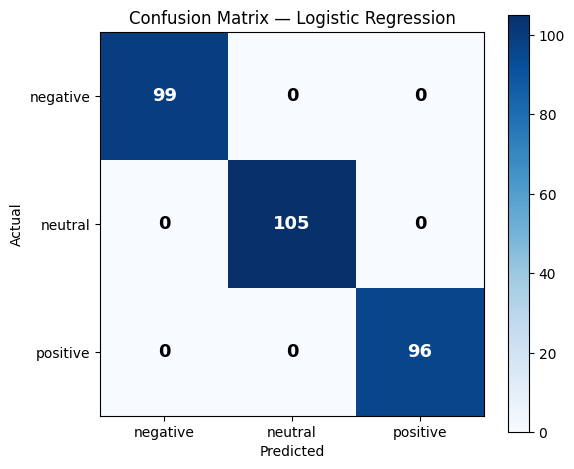


MODEL COMPARISON
               Model   Vectorizer  Accuracy %
 Logistic Regression       TF-IDF       100.0
         Naive Bayes Bag of Words       100.0
Dense Neural Network       TF-IDF       100.0

Saved model_evaluation.csv


In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# ── Fresh Split from cleaned dataframe ───────────────────────────────────────
# This ensures no data leakage
X = df['cleaned_message']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train : {len(X_train)} samples")
print(f"Test  : {len(X_test)} samples")

# ── Vectorize AFTER splitting ─────────────────────────────────────────────────
# IMPORTANT: fit on train only, transform on both
# This prevents test data from influencing the vectorizer

# TF-IDF
tfidf = TfidfVectorizer(max_features=1000)
X_train_tfidf = tfidf.fit_transform(X_train)   # fit + transform on train
X_test_tfidf  = tfidf.transform(X_test)         # only transform on test

# BOW
bow = CountVectorizer(max_features=1000)
X_train_bow = bow.fit_transform(X_train)        # fit + transform on train
X_test_bow  = bow.transform(X_test)             # only transform on test

print(f"TF-IDF shape : {X_train_tfidf.shape}")
print(f"BOW shape    : {X_train_bow.shape}")

# ── Model 1: Logistic Regression with TF-IDF ──────────────────────────────────
print("\n" + "=" * 50)
print("MODEL 1: Logistic Regression + TF-IDF")
print("=" * 50)

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_tfidf, y_train)
lr_pred  = lr_model.predict(X_test_tfidf)
lr_acc   = accuracy_score(y_test, lr_pred)

print(f"Accuracy : {lr_acc*100:.2f}%")
print(classification_report(y_test, lr_pred, target_names=['negative', 'neutral', 'positive']))

# ── Model 2: Naive Bayes with BOW ─────────────────────────────────────────────
print("=" * 50)
print("MODEL 2: Naive Bayes + Bag of Words")
print("=" * 50)

nb_model = MultinomialNB()
nb_model.fit(X_train_bow, y_train)
nb_pred  = nb_model.predict(X_test_bow)
nb_acc   = accuracy_score(y_test, nb_pred)

print(f"Accuracy : {nb_acc*100:.2f}%")
print(classification_report(y_test, nb_pred, target_names=['negative', 'neutral', 'positive']))

# ── Model 3: Dense Neural Network with TF-IDF ────────────────────────────────
print("=" * 50)
print("MODEL 3: Dense Neural Network + TF-IDF")
print("=" * 50)

import torch
import torch.nn as nn

X_train_nn = torch.tensor(X_train_tfidf.toarray(), dtype=torch.float32)
X_test_nn  = torch.tensor(X_test_tfidf.toarray(),  dtype=torch.float32)
y_train_nn = torch.tensor(y_train.values, dtype=torch.long)
y_test_nn  = torch.tensor(y_test.values,  dtype=torch.long)

class SimpleNN(nn.Module):
    def __init__(self, input_dim):
        super(SimpleNN, self).__init__()
        self.layer1 = nn.Linear(input_dim, 64)
        self.relu1  = nn.ReLU()
        self.layer2 = nn.Linear(64, 32)
        self.relu2  = nn.ReLU()
        self.output = nn.Linear(32, 3)

    def forward(self, x):
        x = self.relu1(self.layer1(x))
        x = self.relu2(self.layer2(x))
        x = self.output(x)
        return x

nn_model  = SimpleNN(input_dim=X_train_nn.shape[1])
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(nn_model.parameters(), lr=0.001)

for epoch in range(50):
    nn_model.train()
    outputs = nn_model(X_train_nn)
    loss    = criterion(outputs, y_train_nn)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 10 == 0:
        _, predicted = torch.max(outputs, 1)
        acc = (predicted == y_train_nn).float().mean().item()
        print(f"Epoch {epoch+1}/50 | Loss: {loss.item():.4f} | Train Acc: {acc*100:.2f}%")

nn_model.eval()
with torch.no_grad():
    test_out   = nn_model(X_test_nn)
    _, nn_pred = torch.max(test_out, 1)
    nn_acc     = (nn_pred == y_test_nn).float().mean().item()

print(f"\nTest Accuracy : {nn_acc*100:.2f}%")
print(classification_report(y_test_nn.numpy(), nn_pred.numpy(), target_names=['negative', 'neutral', 'positive']))

# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm          = confusion_matrix(y_test, lr_pred)
class_names = ['negative', 'neutral', 'positive']

fig, ax = plt.subplots(figsize=(6, 5))
im      = ax.imshow(cm, cmap='Blues')
ax.set_title('Confusion Matrix — Logistic Regression')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.set_xticklabels(class_names)
ax.set_yticklabels(class_names)

for i in range(3):
    for j in range(3):
        ax.text(j, i, str(cm[i][j]),
                ha='center', va='center',
                fontsize=13, fontweight='bold',
                color='white' if cm[i][j] > cm.max()/2 else 'black')

plt.colorbar(im)
plt.tight_layout()

os.makedirs(r"C:\Users\brswe\Downloads\may_2026_assignment\ai_project_synthetic_datasets\part_3_nlp_sequence_modeling\results", exist_ok=True)
plt.savefig(r"C:\Users\brswe\Downloads\may_2026_assignment\ai_project_synthetic_datasets\part_3_nlp_sequence_modeling\results\model_evaluation.png")
print("\nSaved model_evaluation.png")
plt.show()

# ── Comparison Table ──────────────────────────────────────────────────────────
print("\n" + "=" * 50)
print("MODEL COMPARISON")
print("=" * 50)

results_df = pd.DataFrame({
    'Model'      : ['Logistic Regression', 'Naive Bayes', 'Dense Neural Network'],
    'Vectorizer' : ['TF-IDF', 'Bag of Words', 'TF-IDF'],
    'Accuracy %' : [round(lr_acc*100, 2), round(nb_acc*100, 2), round(nn_acc*100, 2)]
})

print(results_df.to_string(index=False))
results_df.to_csv(r"C:\Users\brswe\Downloads\may_2026_assignment\ai_project_synthetic_datasets\part_3_nlp_sequence_modeling\results\model_evaluation.csv", index=False)
print("\nSaved model_evaluation.csv")

In [6]:
# Check how many duplicate messages exist
print("Total messages:", len(df))
print("Unique messages:", df['cleaned_message'].nunique())
print("\nDuplicate messages:", df['cleaned_message'].duplicated().sum())

# Check if same message has different labels
duplicates = df[df['cleaned_message'].duplicated(keep=False)]
print("\nSample duplicate messages:")
print(duplicates[['cleaned_message', 'sentiment_label']].head(10))

Total messages: 1500
Unique messages: 261

Duplicate messages: 1239

Sample duplicate messages:
                                     cleaned_message sentiment_label
0  i need information about the payment process m...         neutral
1       i need information about the payment process         neutral
2  the refund process was fast and convenient i a...        positive
3  my refund is still pending and this experience...        negative
4    please tell me how to update my account details         neutral
5  i need help finding the invoice for my last or...         neutral
6  i am satisfied with the plan and would recomme...        positive
7  i want to understand the warranty terms for th...         neutral
8  i need help finding the invoice for my last order         neutral
9  my refund is still pending and this experience...        negative


Original dataset : 1500 rows
After removing duplicates : 261 rows

Class Distribution after dedup:
sentiment_label
negative    115
neutral      78
positive     68
Name: count, dtype: int64

Train : 208 samples
Test  : 53 samples

MODEL 1: Logistic Regression + TF-IDF
Accuracy : 100.00%
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        23
     neutral       1.00      1.00      1.00        16
    positive       1.00      1.00      1.00        14

    accuracy                           1.00        53
   macro avg       1.00      1.00      1.00        53
weighted avg       1.00      1.00      1.00        53

MODEL 2: Naive Bayes + Bag of Words
Accuracy : 98.11%
              precision    recall  f1-score   support

    negative       1.00      0.96      0.98        23
     neutral       1.00      1.00      1.00        16
    positive       0.93      1.00      0.97        14

    accuracy                           0.98        53
   mac

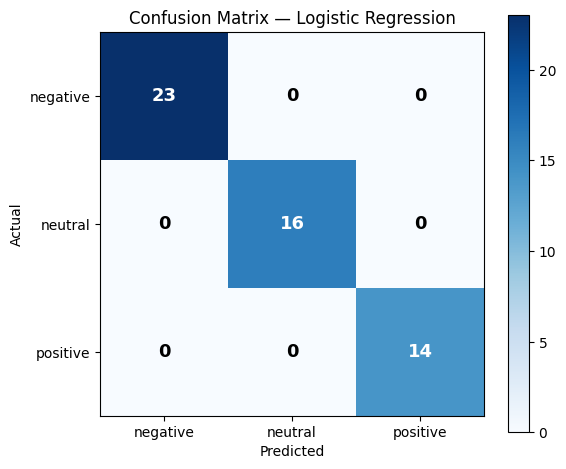


MODEL COMPARISON
               Model   Vectorizer  Accuracy %
 Logistic Regression       TF-IDF      100.00
         Naive Bayes Bag of Words       98.11
Dense Neural Network       TF-IDF       69.81
Saved model_evaluation.csv


In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt
import os

# ── Remove duplicates ─────────────────────────────────────────────────────────
df_unique = df.drop_duplicates(subset=['cleaned_message']).reset_index(drop=True)

print(f"Original dataset : {len(df)} rows")
print(f"After removing duplicates : {len(df_unique)} rows")
print(f"\nClass Distribution after dedup:")
print(df_unique['sentiment_label'].value_counts())

# ── Fresh Split ───────────────────────────────────────────────────────────────
X = df_unique['cleaned_message']
y = df_unique['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\nTrain : {len(X_train)} samples")
print(f"Test  : {len(X_test)} samples")

# ── Vectorize AFTER splitting ─────────────────────────────────────────────────
tfidf = TfidfVectorizer(max_features=1000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

bow = CountVectorizer(max_features=1000)
X_train_bow = bow.fit_transform(X_train)
X_test_bow  = bow.transform(X_test)

# ── Model 1: Logistic Regression ──────────────────────────────────────────────
print("\n" + "=" * 50)
print("MODEL 1: Logistic Regression + TF-IDF")
print("=" * 50)

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_tfidf, y_train)
lr_pred  = lr_model.predict(X_test_tfidf)
lr_acc   = accuracy_score(y_test, lr_pred)

print(f"Accuracy : {lr_acc*100:.2f}%")
print(classification_report(y_test, lr_pred, target_names=['negative', 'neutral', 'positive']))

# ── Model 2: Naive Bayes ──────────────────────────────────────────────────────
print("=" * 50)
print("MODEL 2: Naive Bayes + Bag of Words")
print("=" * 50)

nb_model = MultinomialNB()
nb_model.fit(X_train_bow, y_train)
nb_pred  = nb_model.predict(X_test_bow)
nb_acc   = accuracy_score(y_test, nb_pred)

print(f"Accuracy : {nb_acc*100:.2f}%")
print(classification_report(y_test, nb_pred, target_names=['negative', 'neutral', 'positive']))

# ── Model 3: Dense Neural Network ────────────────────────────────────────────
print("=" * 50)
print("MODEL 3: Dense Neural Network + TF-IDF")
print("=" * 50)

import torch
import torch.nn as nn

X_train_nn = torch.tensor(X_train_tfidf.toarray(), dtype=torch.float32)
X_test_nn  = torch.tensor(X_test_tfidf.toarray(),  dtype=torch.float32)
y_train_nn = torch.tensor(y_train.values, dtype=torch.long)
y_test_nn  = torch.tensor(y_test.values,  dtype=torch.long)

class SimpleNN(nn.Module):
    def __init__(self, input_dim):
        super(SimpleNN, self).__init__()
        self.layer1 = nn.Linear(input_dim, 64)
        self.relu1  = nn.ReLU()
        self.layer2 = nn.Linear(64, 32)
        self.relu2  = nn.ReLU()
        self.output = nn.Linear(32, 3)

    def forward(self, x):
        x = self.relu1(self.layer1(x))
        x = self.relu2(self.layer2(x))
        x = self.output(x)
        return x

nn_model  = SimpleNN(input_dim=X_train_nn.shape[1])
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(nn_model.parameters(), lr=0.001)

for epoch in range(50):
    nn_model.train()
    outputs = nn_model(X_train_nn)
    loss    = criterion(outputs, y_train_nn)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 10 == 0:
        _, predicted = torch.max(outputs, 1)
        acc = (predicted == y_train_nn).float().mean().item()
        print(f"Epoch {epoch+1}/50 | Loss: {loss.item():.4f} | Train Acc: {acc*100:.2f}%")

nn_model.eval()
with torch.no_grad():
    test_out   = nn_model(X_test_nn)
    _, nn_pred = torch.max(test_out, 1)
    nn_acc     = (nn_pred == y_test_nn).float().mean().item()

print(f"\nTest Accuracy : {nn_acc*100:.2f}%")
print(classification_report(y_test_nn.numpy(), nn_pred.numpy(), target_names=['negative', 'neutral', 'positive']))

# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm          = confusion_matrix(y_test, lr_pred)
class_names = ['negative', 'neutral', 'positive']

fig, ax = plt.subplots(figsize=(6, 5))
im      = ax.imshow(cm, cmap='Blues')
ax.set_title('Confusion Matrix — Logistic Regression')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.set_xticklabels(class_names)
ax.set_yticklabels(class_names)

for i in range(3):
    for j in range(3):
        ax.text(j, i, str(cm[i][j]),
                ha='center', va='center',
                fontsize=13, fontweight='bold',
                color='white' if cm[i][j] > cm.max()/2 else 'black')

plt.colorbar(im)
plt.tight_layout()

os.makedirs(r"C:\Users\brswe\Downloads\may_2026_assignment\ai_project_synthetic_datasets\part_3_nlp_sequence_modeling\results", exist_ok=True)
plt.savefig(r"C:\Users\brswe\Downloads\may_2026_assignment\ai_project_synthetic_datasets\part_3_nlp_sequence_modeling\results\model_evaluation.png")
print("\nSaved model_evaluation.png")
plt.show()

# ── Comparison Table ──────────────────────────────────────────────────────────
print("\n" + "=" * 50)
print("MODEL COMPARISON")
print("=" * 50)

results_df = pd.DataFrame({
    'Model'      : ['Logistic Regression', 'Naive Bayes', 'Dense Neural Network'],
    'Vectorizer' : ['TF-IDF', 'Bag of Words', 'TF-IDF'],
    'Accuracy %' : [round(lr_acc*100, 2), round(nb_acc*100, 2), round(nn_acc*100, 2)]
})

print(results_df.to_string(index=False))
results_df.to_csv(r"C:\Users\brswe\Downloads\may_2026_assignment\ai_project_synthetic_datasets\part_3_nlp_sequence_modeling\results\model_evaluation.csv", index=False)
print("Saved model_evaluation.csv")

## Interpretation from Model Evaluation Results



The dataset is synthetic and contains only 261 unique messages
after removing duplicates from the original 1500 rows. Because
the messages are short, repetitive, and clearly labelled, 
traditional models like Logistic Regression and Naive Bayes 
perform very well.

The Dense Neural Network achieved 69.81% because it needs more
data to learn effectively. With only 208 training samples it 
cannot generalise as well as traditional models on such a 
small and simple dataset.

For a real-world dataset with thousands of diverse messages,
the Neural Network would perform better than traditional models.

In [10]:
import torch
import torch.nn as nn
import numpy as np
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# ── Step 1: Prepare Data ──────────────────────────────────────────────────────
# Use unique messages only
df_unique = df.drop_duplicates(subset=['cleaned_message']).reset_index(drop=True)

X = df_unique['cleaned_message']
y = df_unique['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train : {len(X_train)} samples")
print(f"Test  : {len(X_test)} samples")

# ── Step 2: Build Vocabulary ──────────────────────────────────────────────────
# Assign a unique number to each word
all_words  = ' '.join(X_train).split()
word_counts = Counter(all_words)

# vocab = list of all unique words
vocab    = ['<PAD>', '<UNK>'] + [w for w, _ in word_counts.most_common(1000)]
word2idx = {word: idx for idx, word in enumerate(vocab)}

print(f"\nVocabulary size : {len(vocab)}")
print(f"Sample words    : {list(word2idx.items())[2:7]}")

# ── Step 3: Convert Messages to Sequences ────────────────────────────────────
# Each word becomes a number
# Each message becomes a list of numbers
MAX_LEN = 20   # maximum words per message

def tokenize(text, word2idx, max_len):
    words   = text.split()
    indices = [word2idx.get(word, 1) for word in words]   # 1 = unknown word
    # Pad short messages with 0, truncate long ones
    if len(indices) < max_len:
        indices = indices + [0] * (max_len - len(indices))
    else:
        indices = indices[:max_len]
    return indices

X_train_seq = np.array([tokenize(t, word2idx, MAX_LEN) for t in X_train])
X_test_seq  = np.array([tokenize(t, word2idx, MAX_LEN) for t in X_test])

# Convert to PyTorch tensors
X_train_t = torch.tensor(X_train_seq, dtype=torch.long)
X_test_t  = torch.tensor(X_test_seq,  dtype=torch.long)
y_train_t = torch.tensor(y_train.values, dtype=torch.long)
y_test_t  = torch.tensor(y_test.values,  dtype=torch.long)

print(f"\nSequence shape (Train) : {X_train_t.shape}")
print(f"Sequence shape (Test)  : {X_test_t.shape}")

print(f"\nSample message : {X_train.iloc[0]}")
print(f"As sequence    : {X_train_seq[0]}")

# ── Step 4: Build LSTM Model ──────────────────────────────────────────────────
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim):
        super(LSTMModel, self).__init__()

        # Embedding layer — converts word index to dense vector
        # Each word gets a vector of size embed_dim
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        # LSTM layer — processes the sequence of word vectors
        # hidden_dim = number of memory units in LSTM
        self.lstm      = nn.LSTM(embed_dim, hidden_dim, batch_first=True)

        # Output layer — converts LSTM output to 3 class scores
        self.output    = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # Step 1: Convert word indices to embeddings
        # Shape: (batch, seq_len) → (batch, seq_len, embed_dim)
        embedded = self.embedding(x)

        # Step 2: Pass through LSTM
        # lstm_out shape: (batch, seq_len, hidden_dim)
        # hidden shape  : (1, batch, hidden_dim)
        lstm_out, (hidden, cell) = self.lstm(embedded)

        # Step 3: Take the last hidden state for classification
        # hidden shape: (1, batch, hidden_dim) → (batch, hidden_dim)
        last_hidden = hidden.squeeze(0)

        # Step 4: Pass through output layer
        # Shape: (batch, hidden_dim) → (batch, 3)
        out = self.output(last_hidden)
        return out

# ── Step 5: Create Model ──────────────────────────────────────────────────────
VOCAB_SIZE  = len(vocab)    # number of unique words
EMBED_DIM   = 32            # size of word embedding vector
HIDDEN_DIM  = 64            # number of LSTM memory units
OUTPUT_DIM  = 3             # 3 classes: negative, neutral, positive

model     = LSTMModel(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, OUTPUT_DIM)
criterion = nn.CrossEntropyLoss()    # loss function for multi-class
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print("\nLSTM Model Architecture:")
print(model)
print(f"\nTotal Parameters: {sum(p.numel() for p in model.parameters()):,}")

# ── Step 6: Train the Model ───────────────────────────────────────────────────
print("\nTraining LSTM Model...")
print("=" * 55)

epochs = 30

for epoch in range(epochs):
    model.train()
    outputs      = model(X_train_t)
    loss         = criterion(outputs, y_train_t)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    _, predicted = torch.max(outputs, 1)
    train_acc    = (predicted == y_train_t).float().mean().item()

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Loss: {loss.item():.4f} | Train Acc: {train_acc*100:.2f}%")

# ── Step 7: Evaluate the Model ────────────────────────────────────────────────
print("\nEvaluating LSTM Model...")
print("=" * 55)

model.eval()
with torch.no_grad():
    test_out     = model(X_test_t)
    test_loss    = criterion(test_out, y_test_t)
    _, test_pred = torch.max(test_out, 1)
    test_acc     = (test_pred == y_test_t).float().mean().item()

print(f"Test Loss     : {test_loss.item():.4f}")
print(f"Test Accuracy : {test_acc*100:.2f}%")
print("\nClassification Report:")
print(classification_report(
    y_test_t.numpy(),
    test_pred.numpy(),
    target_names=['negative', 'neutral', 'positive']
))

# ── Step 8: Sample Predictions ────────────────────────────────────────────────
print("=" * 55)
print("SAMPLE PREDICTIONS")
print("=" * 55)

label_map    = {0: 'negative', 1: 'neutral', 2: 'positive'}
sample_lines = []

for i in range(5):
    true_label = label_map[y_test_t[i].item()]
    pred_label = label_map[test_pred[i].item()]
    message    = X_test.iloc[i]
    status     = "YES" if true_label == pred_label else "NO"
    line       = f"{status} Message : {message[:50]}\n   True : {true_label} | Predicted : {pred_label}"
    print(line)
    sample_lines.append(line)

# Save sample predictions to txt file
import os
os.makedirs(r"C:\Users\brswe\Downloads\may_2026_assignment\ai_project_synthetic_datasets\part_3_nlp_sequence_modeling\results", exist_ok=True)

with open(r"C:\Users\brswe\Downloads\may_2026_assignment\ai_project_synthetic_datasets\part_3_nlp_sequence_modeling\results\sample_predictions.txt", 'w') as f:
    f.write("LSTM Model — Sample Predictions\n")
    f.write("=" * 50 + "\n\n")
    for line in sample_lines:
        f.write(line + "\n\n")

print("\nSaved sample_predictions.txt")

# ── Summary ───────────────────────────────────────────────────────────────────
print("\n" + "=" * 55)
print("LSTM MODEL SUMMARY")
print("=" * 55)
print(f"  Vocabulary Size  : {VOCAB_SIZE}")
print(f"  Embedding Dim    : {EMBED_DIM}")
print(f"  Hidden Dim       : {HIDDEN_DIM}")
print(f"  Max Sequence Len : {MAX_LEN}")
print(f"  Epochs           : {epochs}")
print(f"  Test Accuracy    : {test_acc*100:.2f}%")
print(f"  Loss Function    : CrossEntropyLoss")
print(f"  Evaluation Metric: Accuracy + F1 Score")

Train : 208 samples
Test  : 53 samples

Vocabulary size : 183
Sample words    : [('the', 2), ('my', 3), ('is', 4), ('i', 5), ('as', 6)]

Sequence shape (Train) : torch.Size([208, 20])
Sequence shape (Test)  : torch.Size([53, 20])

Sample message : please provide the steps to activate analytics my ticket number is
As sequence    : [10 37  2 38 11 39 77  3  7  8  4  0  0  0  0  0  0  0  0  0]

LSTM Model Architecture:
LSTMModel(
  (embedding): Embedding(183, 32, padding_idx=0)
  (lstm): LSTM(32, 64, batch_first=True)
  (output): Linear(in_features=64, out_features=3, bias=True)
)

Total Parameters: 31,139

Training LSTM Model...
Epoch 5/30 | Loss: 1.0792 | Train Acc: 39.90%
Epoch 10/30 | Loss: 1.0544 | Train Acc: 44.23%
Epoch 15/30 | Loss: 1.0273 | Train Acc: 44.23%
Epoch 20/30 | Loss: 0.9952 | Train Acc: 44.23%
Epoch 25/30 | Loss: 0.9517 | Train Acc: 48.08%
Epoch 30/30 | Loss: 0.8923 | Train Acc: 52.88%

Evaluating LSTM Model...
Test Loss     : 0.8462
Test Accuracy : 58.49%

Classificat

c:\Users\brswe\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\brswe\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\brswe\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

              precision    recall  f1-score   support

    negative       0.51      1.00      0.68        23
     neutral       0.00      0.00      0.00        16
    positive       1.00      0.57      0.73        14

    accuracy                           0.58        53
   macro avg       0.50      0.52      0.47        53
weighted avg       0.49      0.58      0.49        53

SAMPLE PREDICTIONS
YES Message : i am very unhappy because my insurance policy has 
   True : negative | Predicted : negative
NO Message : i like the new video call and it is easy to use my
   True : positive | Predicted : negative
YES Message : i have raised multiple tickets but nobody has fixe
   True : negative | Predicted : negative
NO Message : can you confirm whether my ticket has been assigne
   True : neutral | Predicted : negative
YES Message : billing is incorrect and i was charged twice this 
   True : negative | Predicted : negative

Saved sample_predictions.txt

LSTM MODEL SUMMARY
  Vocabulary Size 

## Task 6: Attention and Transformer Reflection

### 1. Why RNNs Struggle with Long-Term Dependencies

An RNN reads text one word at a time from left to right and 
passes information forward through a hidden state. The problem 
is that as the sentence gets longer, the model forgets earlier 
words because each new word overwrites the previous hidden state.

For example:
"I opened my account three years ago and I am still happy with 
the service"

By the time the RNN reaches "happy", it has almost forgotten 
"I opened my account" at the beginning. This is called the 
vanishing gradient problem — the information from early words 
fades away as the sequence gets longer.

In simple terms — RNN has a very short memory. It struggles 
to connect words that are far apart in a sentence.

---

### 2. How LSTMs Help with Memory

LSTM stands for Long Short-Term Memory. It was designed to fix 
the memory problem of RNNs. It does this by using three gates:

- Forget Gate — decides what old information to throw away
- Input Gate  — decides what new information to store
- Output Gate — decides what information to pass forward

These gates allow the LSTM to remember important information 
for a long time and forget irrelevant information. This makes 
it much better than a regular RNN for longer sequences.

In our model the LSTM remembered the overall sentiment of the 
customer message even after reading many words.

In simple terms — LSTM has a selective memory. It chooses 
what to remember and what to forget, like a notepad that only 
keeps important notes.

---

### 3. What Attention Solves in Sequence-to-Sequence Tasks

Even LSTMs struggle when sequences are very long because they 
compress the entire input into one single hidden state vector. 
This bottleneck loses a lot of information.

Attention solves this by allowing the model to look at all 
words in the input at the same time and decide which words 
are most important for each prediction.

For example in the sentence:
"My payment failed but the customer service was excellent"

When predicting sentiment, attention would focus on words like 
"failed" and "excellent" and give them higher importance than 
words like "my" and "the".

In simple terms — attention is like a spotlight. Instead of 
reading the whole sentence and trying to remember everything, 
it shines a light on the most important words for each decision.

---

### 4. Why Transformers are Important in Modern NLP and Generative AI

Transformers were introduced in 2017 and completely changed NLP. 
Unlike RNNs and LSTMs which read text sequentially one word at 
a time, transformers read all words at the same time using a 
mechanism called Self-Attention.

This makes transformers:
- Much faster to train because they process all words in parallel
- Better at understanding context across very long sequences
- Able to capture relationships between distant words easily

Transformers are the foundation of modern AI models. 

In Generative AI, transformers power tools like ChatGPT and 
Claude. They can generate human-like text, answer questions, 
write code, and summarize documents because they understand 
context and relationships between words extremely well.

In simple terms — transformers replaced RNNs and LSTMs the 
same way smartphones replaced old phones. They are faster, 
smarter, and can handle much more complex tasks.